# Encoder-Only Transformer model

**Auteur**: `Jakob De Vreese`  
**Bachelorproef**: Overdraagbare unsupervised anomaliedetectie bij hybride HVAC-systemen  
**Academiejaar**: `2025-2026`  

## Doel

Het implementeren van een **Encoder-Only Transformer** architectuur voor de detectie van anomalieën in _hybride HVAC-systemen_, gebaseerd op de paper `Transformer encoder based self-supervised learning for HVAC fault detection with unlabeled data` [(Abdollah et al., 2024)](http://dx.doi.org/10.1016/j.buildenv.2024.111568}).

### Verwachte brondata

Pre-processed multivariate dataset met HVAC-systeemdata (bijv. 10-minuten resolutie).

### Concept lagen

#### A. Pre-processing & Embedding

- **Normalisatie**
- **Time2Vec**
- **Learnable Positional Encoding**

#### B. Self-Supervised Learning (Pre-training)

- **Markov Chain Masking**
- **Masked MSE Loss**

#### C. Anomaliedetectie en Diagnostiek

- **Anomaliescore**
- **Peak Over Threshold (POT)**

### Stappenplan

- **Stap 1**: Data processing (split train, val, test e.a.)
- **Stap 2**: De Encoder-Only Architectuur (Keras/TensorFlow implementatie inclusief Time2Vec)
- **Stap 3**: Self-Supervised Training (Markov chain block masking & MSE-loss)
- **Stap 4**: Keras Training via overschreven `train_step`
- **Stap 5**: Hyperparameter Tuning (KerasTuner) & Model Opslaan
- **Stap 6**: Inferentie & Anomaliescores
- **Stap 7**: Validatie met Synthetische data

In [24]:
import pandas as pd
import numpy as np
import keras
from sklearn.preprocessing import StandardScaler
import joblib
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

## STAP 1 - Data Preprocessing

Voordat de data in het Keras-model wordt gevoed, wordt de volgende voorbereiding uitgevoerd:

1. **Data inlezen**
2. **Feature reductie**
3. **Data opsplitsen**
4. **Normalisatie**
5. **Windowing (3d-tensors)**

### 1.1 Dataset inlezen

In [2]:
# Dataset inlezen
GEBOUW = 'dunant1'

url = f'../02_eda_en_ground_truth/processed/{GEBOUW}_train.csv'
data = pd.read_csv(url)
data.head()

,timestamp,f_1,f_2,f_3,f_4,f_6,f_7,f_8,f_9,f_10,...,f_50,f_51,f_52,f_53,f_54,f_55,is_weekdag,is_weekend,is_werkuur,uur
0,2026-03-09 00:10:00+00:00,7.0,0.77,1.0,39.877285,31.832268,1.0,23.594538,44.640636,1.0,...,0.0,3.851797,99.589400,0.749325,86.946641,0.0,1,0,0,0
1,2026-03-09 00:20:00+00:00,9.0,0.78,1.0,41.921010,34.104786,1.0,46.930084,44.640636,1.0,...,0.0,3.903977,100.000000,0.559565,45.771835,0.0,1,0,0,0
2,2026-03-09 00:30:00+00:00,8.0,0.86,1.0,43.412975,35.585346,1.0,43.235270,44.640636,0.0,...,0.0,4.244891,99.196013,0.322963,91.228401,0.0,1,0,0,0
3,2026-03-09 00:40:00+00:00,7.0,0.78,1.0,43.734930,35.924030,1.0,48.845810,44.640636,0.0,...,0.0,4.448537,98.800579,0.300000,323.796930,0.0,1,0,0,0
4,2026-03-09 00:50:00+00:00,9.0,0.78,1.0,44.037724,36.229050,1.0,44.068630,44.640636,0.0,...,0.0,4.748848,99.259927,0.345344,204.933704,0.0,1,0,0,0


In [3]:
print(data.shape)

(4146, 59)


### 1.2 Feature reductie

Om het model zo efficiënt mogelijk te maken verwijderen ze in de paper één feature per paar met een correlatie **boven 95%**.

In [4]:
# Bereken correlatie
corr_matrix = data.drop(columns=['timestamp']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificeer kolommen die WEG moeten
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

# Identificeer kolommen die we BEHOUDEN (behalve timestamp)
kept_features = [col for col in data.columns if col not in to_drop and col != 'timestamp']

print(f"Aantal behouden features: {len(kept_features)}")
# Sla deze lijst op voor later!
import json
with open(f'encoder_only/features_{GEBOUW}.json', 'w') as f:
    json.dump(kept_features, f)

data_filtered = data[kept_features]

Aantal behouden features: 44


### 1.3 Data opspliten

In [5]:
n = len(data)
train_df = data_filtered[0:int(n*0.7)]
val_df = data_filtered[int(n*0.7):int(n*0.85)]
test_df = data_filtered[int(n*0.85):]

### 1.4 Normalisatie (Z-score Scaling)

Volgens de paper moeten we de data standaardiseren. We normaliseren `train_df` en gebruiken de parameters om dit ook op de rest toe te passen.

In [6]:
scaler = StandardScaler()

# Fit alleen op training data
scaler.fit(train_df)

# Transformeer alle sets
train_scaled = scaler.transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

# Sla de scaler op voor later gebruik in productie!
joblib.dump(scaler, f'encoder_only/scaler_{GEBOUW}.pkl')

['encoder_only/scaler_dunant1.pkl']

### 1.5 Windowing (3D Tensor maken)

De `Transformer` heeft een venster nodig van data om patronen te herkennen. In de paper gebruikt men venstergroottes ($w$) van 1 dag of wel 144 tijdstappen.

In [7]:
def create_windows(data_array, window_size=144):
    X = []
    for i in range(len(data_array) - window_size):
        X.append(data_array[i:i + window_size])
    return np.array(X)

# Maak de 3D tensors: (samples, window_size, features)
X_train = create_windows(train_scaled, window_size=144)
X_val = create_windows(val_scaled, window_size=144)
X_test = create_windows(test_scaled, window_size=144)

print(f"Shape training data: {X_train.shape}")

Shape training data: (2758, 144, 44)


## STAP 2 - De Encoder-Only Architectuur

In deze stap bouwen we het model in `Keras`. We wijken af van de standaard encoder-decoder structuur en gebruiken een **encoder-only** model, wat de comutationele complexiteit verlaagt.

### De lagen

#### Preprocessing & encoding

- **Normalization**
- **Linear projection**
- **Time2Vec**
- **Learnable Positional Encoding**

#### Transformer encoder blocs

- **Multi-Head Attention (MHA)**
- **Point-wise Feedforward Netword (FFN)**
- **Residual Connections & LayerNorm**

#### Reconstruction Step

- **Output Projection**



### Time2Vec

In [8]:
class Time2Vec(layers.Layer):
    def __init__(self, kernel_size=1):
        super(Time2Vec, self).__init__()
        self.k = kernel_size

    def build(self, input_shape):
        # Gewichten voor de lineaire component (trend)
        self.wb = self.add_weight(name='wb', shape=(input_shape[1], 1), initializer='uniform', trainable=True)
        self.bb = self.add_weight(name='bb', shape=(input_shape[1], 1), initializer='uniform', trainable=True)
        # Gewichten voor de periodieke component (sinus)
        self.wa = self.add_weight(name='wa', shape=(input_shape[1], self.k), initializer='uniform', trainable=True)
        self.ba = self.add_weight(name='ba', shape=(input_shape[1], self.k), initializer='uniform', trainable=True)

    def call(self, inputs):
        # Inputs zijn hier de tijdstappen (bijv. van 0 tot 143)
        bias = self.wb * inputs + self.bb
        # Periodieke activatie om cycli te herkennen
        dp = tf.sin(self.wa * inputs + self.ba)
        return tf.concat([bias, dp], axis=-1)

### Transformer Encoder blok

In [9]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # 1. Multi-Head Attention[cite: 1]
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    # 2. Add & Norm (Residual Connection)[cite: 1]
    res = x + inputs
    x = layers.LayerNormalization(epsilon=1e-6)(res)

    # 3. Point-wise Feedforward Network[cite: 1]
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    # 4. Add & Norm[cite: 1]
    x = x + res
    return layers.LayerNormalization(epsilon=1e-6)(x)

### Het volledige model

In [10]:
def build_model(window_size, num_features, d_model, num_heads, ff_dim, num_layers, dropout):
    inputs = layers.Input(shape=(window_size, num_features))
    
    # --- STAP 1: Preprocessing & Encoding ---
    # Normalisatie voor trainingsstabiliteit[cite: 1]
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    
    # Lineaire projectie naar model dimensie 'd'[cite: 1]
    x = layers.Dense(d_model)(x)
    
    # Learnable Positional Encoding toevoegen[cite: 1]
    pos_emb = layers.Embedding(input_dim=window_size, output_dim=d_model)(tf.range(start=0, limit=window_size, delta=1))
    x = x + pos_emb

    # --- STAP 2: Transformer Processing ---
    # Stapel 'B' aantal encoder layers[cite: 1]
    for _ in range(num_layers):
        x = transformer_encoder(x, d_model, num_heads, ff_dim, dropout)

    # --- STAP 3: Reconstruction Step ---
    # Terugmappen naar de originele dimensie 'm'[cite: 1]
    outputs = layers.Dense(num_features)(x)
    
    return tf.keras.Model(inputs, outputs)

In [11]:
# Voorbeeld initialisatie met parameters uit de paper
model = build_model(
    window_size=144, 
    num_features=len(kept_features), 
    d_model=64, 
    num_heads=7, 
    ff_dim=64, 
    num_layers=2, 
    dropout=0.1
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 144, 44)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 144, 44)   │         88 │ input_layer[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 144, 64)   │      2,880 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 144, 64)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 144, 64)   │    116,096 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 144, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 144, 64)   │          0 │ dropout_1[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 144, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 144, 64)   │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 144, 64)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 144, 64)   │      4,160 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 144, 64)   │          0 │ dense_2[0][0],    │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 144, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 144, 64)   │    116,096 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 144, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 144, 64)   │          0 │ dropout_4[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 144, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 144, 64)   │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 144, 64)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 144, 64)   │      4,160 │ dropout_5[0][0] 

 Total params: 255,172 (996.77 KB)

 Trainable params: 255,172 (996.77 KB)

 Non-trainable params: 0 (0.00 B)

## Stap 3 - Self-Supervised Pre-training (Markov Chain Masking)

We gebruiken een Markov-keten met twee toestanden (Masked/Unmasked). De lengte van de segmenten volgt een geometrische distributie met 2 parameters:

- $l_m$: De gemiddelde lengte van een verborgen segment (de paper stelt $l_m=3$ voor)
- $r$: De proportie van de totale data die we willen maskeren (vaak rond 15-20%)

De gemiddelde lengte van een ongemaskeerd element word dan berekend als

$$
l_u = \frac{1 - r}{r} . l_m
$$

In [12]:
def generate_markov_mask(input_shape, r=0.15, lm=3):
    """
    Genereert een binaire mask matrix (M) op basis van een Markov Chain.
    Input_shape: (window_size, num_features)
    """
    W, M = input_shape
    # Bereken de gemiddelde ongemaskeerde lengte
    lu = ((1 - r) / r) * lm
    
    # Transitie kansen (p_m: 1->0, p_u: 0->1)
    p_m = 1 / lu
    p_u = 1 / lm
    
    mask = np.ones(input_shape)
    
    for j in range(M): # Per feature
        curr_state = 1 # Start als unmasked
        for i in range(W):
            if curr_state == 1:
                if np.random.rand() < p_m:
                    curr_state = 0
            else:
                if np.random.rand() < p_u:
                    curr_state = 1
            mask[i, j] = curr_state
            
    return mask

Dit is een cruciale stap: we willen dat het model alleen gestraft wordt voor fouten in de segmenten die we verborgen hebben. We berekenen de verlieswaarde dus uitsluitend op de posities waar de mask waarde 0 is.

In [13]:
def masked_mse_loss(y_true, y_pred, mask):
    """
    Berekent MSE uitsluitend op de gemaskeerde segmenten.
    """
    # De paper berekent loss enkel op de verborgen delen (waar mask == 0)
    # We maken een invers masker: 1 voor verborgen, 0 voor zichtbaar
    inverse_mask = 1.0 - tf.cast(mask, tf.float32)
    
    sq_diff = tf.square(y_true - y_pred) * inverse_mask
    
    # Gemiddelde nemen over het aantal gemaskeerde punten
    loss = tf.reduce_sum(sq_diff) / (tf.reduce_sum(inverse_mask) + 1e-6)
    return loss

We maken een klasse die het basismodel (de Transformer) inkapselt en de train_step overschrijft om de Markov-maskering toe te passen.

In [14]:
class HVACModel(tf.keras.Model):
    def __init__(self, transformer_model, r=0.15, lm=3):
        super(HVACModel, self).__init__()
        self.transformer = transformer_model
        self.r = r
        self.lm = lm
        self.loss_tracker = tf.keras.metrics.Mean(name="masked_mse")

    def train_step(self, data):
        # Gebruik x.shape voor statische dimensies (integers) in plaats van tf.shape
        x = data
        window_size = x.shape[1]  # Dit geeft de integer 144
        num_features = x.shape[2] # Dit geeft de integer 44
        batch_size = tf.shape(x)[0] # Batch size mag dynamisch blijven

        # 1. Genereer masker
        # We geven de shape mee als een lijst van integers
        mask = tf.numpy_function(
            func=generate_markov_mask,
            inp=[[window_size, num_features], self.r, self.lm],
            Tout=tf.float64
        )
        mask = tf.cast(mask, dtype=tf.float32)
        
        # Fix: Gebruik de integers om de shape te herstellen
        mask.set_shape((window_size, num_features))
        
        # Breid uit naar batch
        mask_batch = tf.repeat(tf.expand_dims(mask, 0), batch_size, axis=0)
        mask_batch.set_shape(x.shape)

        # 2. Maskeren en trainen
        x_masked = x * mask_batch
        with tf.GradientTape() as tape:
            y_pred = self.transformer(x_masked, training=True)
            loss = masked_mse_loss(x, y_pred, mask_batch) # Loss op verborgen delen[cite: 1]

        gradients = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        return {"masked_mse": self.loss_tracker.result()}

    def test_step(self, data):
        """Nodig om de val_masked_mse correct te berekenen tijdens fit()[cite: 1]"""
        # Fit() stuurt (x, y) naar test_step, in jouw geval is y ook X_val
        x, y = data 
        
        window_size = x.shape[1]
        num_features = x.shape[2]
        batch_size = tf.shape(x)[0]

        mask = tf.numpy_function(
            func=generate_markov_mask,
            inp=[[window_size, num_features], self.r, self.lm],
            Tout=tf.float64
        )
        mask = tf.cast(mask, dtype=tf.float32)
        mask.set_shape((window_size, num_features))
        mask_batch = tf.repeat(tf.expand_dims(mask, 0), batch_size, axis=0)
        mask_batch.set_shape(x.shape)

        x_masked = x * mask_batch
        y_pred = self.transformer(x_masked, training=False)
        loss = masked_mse_loss(x, y_pred, mask_batch)

        self.loss_tracker.update_state(loss)
        return {"masked_mse": self.loss_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker]

    def call(self, inputs):
        return self.transformer(inputs)

In [15]:
# Maak de kern
base_transformer = build_model(
    window_size=144, 
    num_features=len(kept_features),
    d_model=64, 
    num_heads=7, 
    ff_dim=128, 
    num_layers=2, 
    dropout=0.1
)

# Maak de HVAC wrapper voor self-supervised training
hvac_model = HVACModel(base_transformer, r=0.15, lm=3)
hvac_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))

## Stap 4: Keras Training & Monitoring

In deze fase brengen we alles samen. Hoewel we de train_step handmatig hebben overschreven, gebruiken we de krachtige standaardfunctionaliteiten van Keras voor de uitvoering.

### Kernonderdelen van de training

- Optimizer (Adam): De paper maakt gebruik van de Adam optimizer, die de leersnelheid tijdens het proces dynamisch aanpast voor snellere convergentie.  
- EarlyStopping: Dit stopt de training automatisch zodra de loss op de validatieset niet meer verbetert, wat essentieel is bij Transformers om onnodige rekenkracht te besparen.  
- ModelCheckpoint: Omdat de loss tijdens de training kan fluctueren door de dynamische maskering, slaan we alleen de versie van het model op die het beste presteert op de validatiedata.  
- Validation: We monitoren de prestaties op data die het model niet gebruikt voor de gewichtsaanpassingen, om te verifiëren of de geleerde correlaties overdraagbaar zijn naar nieuwe situaties.

### 4.1 Callbacks en Optimizer configureren

Voordat we de training starten, definiëren we de "bewakers" van ons proces. Deze zorgen ervoor dat we niet blindelings blijven trainen.

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. Optimizer: Adam met een bescheiden leersnelheid (LR) zoals in de paper
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# 2. EarlyStopping: Stop als de validatie-loss 10 epochs niet meer zakt
early_stopping = EarlyStopping(
    monitor='val_masked_mse', 
    patience=10, 
    restore_best_weights=True,
    mode='min'
)

# 3. ModelCheckpoint: Sla de beste gewichten op in een bestand
checkpoint = ModelCheckpoint(
    filepath=f'encoder_only/best_model_{GEBOUW}.weights.h5',
    monitor='val_masked_mse',
    save_best_only=True,
    save_weights_only=True, # We slaan gewichten op omdat we een custom model gebruiken
    mode='min'
)

# 4. ReduceLROnPlateau: Verlaag de LR als de training stagneert
reduce_lr = ReduceLROnPlateau(
    monitor='val_masked_mse', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-6,
    mode='min'
)

callbacks = [early_stopping, checkpoint, reduce_lr]

### 4.2 De Training uitvoeren

We roepen nu de .fit() methode aan. Let op: we geven X_train mee als zowel de input als de target, maar onze custom train_step zal intern de maskering regelen en de loss berekenen.

In [20]:
hvac_model.build(input_shape=(None, 144, len(kept_features)))

# Compileer het HVAC wrapper model
hvac_model.compile(optimizer=optimizer)

# Start het leerproces
history = hvac_model.fit(
    X_train, 
    epochs=100,            # Maximaal 100, EarlyStopping grijpt waarschijnlijk eerder in
    batch_size=32,         # Batch grootte aanpasbaar voor GPU/CPU geheugen
    validation_data=(X_val, X_val), 
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 37s 397ms/step - masked_mse: 0.4551 - val_masked_mse: 0.9369 - learning_rate: 1.0000e-04
Epoch 2/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 33s 381ms/step - masked_mse: 0.3845 - val_masked_mse: 0.8898 - learning_rate: 1.0000e-04
Epoch 3/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 34s 389ms/step - masked_mse: 0.3349 - val_masked_mse: 0.6248 - learning_rate: 1.0000e-04
Epoch 4/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 35s 397ms/step - masked_mse: 0.3042 - val_masked_mse: 0.7786 - learning_rate: 1.0000e-04
Epoch 5/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 34s 396ms/step - masked_mse: 0.2777 - val_masked_mse: 0.7590 - learning_rate: 1.0000e-04
Epoch 6/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 35s 396ms/step - masked_mse: 0.2616 - val_masked_mse: 0.7383 - learning_rate: 1.0000e-04
Epoch 7/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 35s 407ms/step - masked_mse: 0.2498 - val_masked_mse: 0.6533 - learning_rate: 1.0000e-04
Epoch 8/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 36s 411ms/step - masked_mse: 0.2344 - val_masked_mse: 0.5337 - le

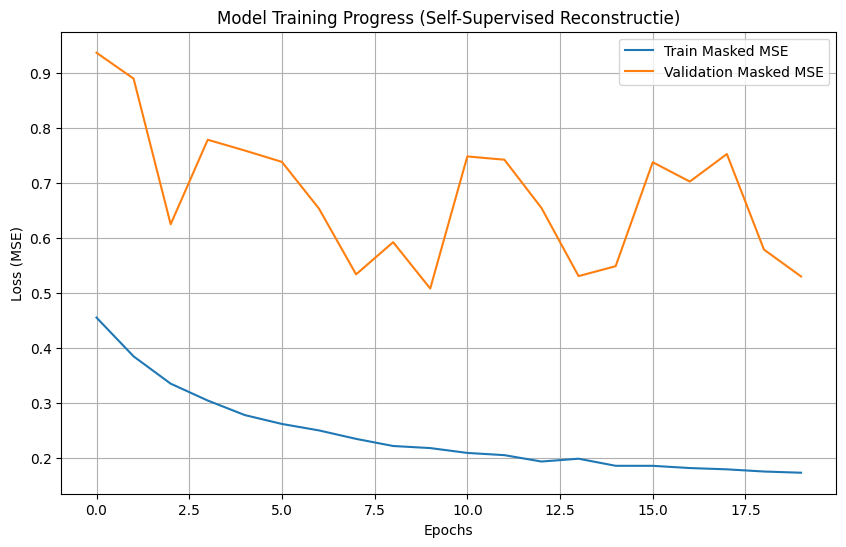

In [25]:
def plot_history(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['masked_mse'], label='Train Masked MSE')
    plt.plot(history.history['val_masked_mse'], label='Validation Masked MSE')
    plt.title('Model Training Progress (Self-Supervised Reconstructie)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history)

### Validatie initiele model

Nu testen we het initiele model tegenover de ground truth

Ground truth inladen

In [26]:
 # Gelabelde synthetische evaluatieset inladen
synth_csv = f'../02_eda_en_ground_truth/processed/{GEBOUW}_test.csv'
labels_npy = f'../02_eda_en_ground_truth/processed/{GEBOUW}_test_labels.npy'

synth_df = pd.read_csv(synth_csv)
y_true_timestep = np.load(labels_npy).astype(int) 

In [27]:
import json
import joblib

# 1. Laad de bewaarde featurelijst en de scaler
with open(f'encoder_only/features_{GEBOUW}.json', 'r') as f:
    kept_features = json.load(f)

scaler = joblib.load(f'encoder_only/scaler_{GEBOUW}.pkl')

# 2. Filter en schaal de synthetische dataset
synth_df_filtered = synth_df[kept_features]
synth_scaled = scaler.transform(synth_df_filtered)

# 3. Maak windows van 144 stappen (24 uur)
X_eval = create_windows(synth_scaled, window_size=144)

print(f"Shape van de evaluatie windows: {X_eval.shape}")

Shape van de evaluatie windows: (317, 144, 44)


In [28]:
def align_labels_to_windows(y_true_timestep, window_size=144):
    """
    Converteert tijdstap-labels naar window-labels.
    """
    y_true_window = []
    # We lopen tot len(y_true_timestep) - window_size, net als bij create_windows
    for i in range(len(y_true_timestep) - window_size):
        # Als er een 1 in het window zit, is het window 1
        window_label = 1 if np.any(y_true_timestep[i : i + window_size] == 1) else 0
        y_true_window.append(window_label)
    return np.array(y_true_window)

y_true_window = align_labels_to_windows(y_true_timestep, window_size=144)
print(f"Shape van de window labels: {y_true_window.shape}")

Shape van de window labels: (317,)


In [29]:
# 1. Verkrijg de reconstructies van het model
# We gebruiken de interne transformer van onze wrapper
reconstructions = hvac_model.transformer.predict(X_eval)

# 2. Bereken de MSE per window (Mean Squared Error over features en tijdstappen)
# Dit geeft één score per window
eval_scores_best = np.mean(np.square(X_eval - reconstructions), axis=(1, 2))

print(f"Aantal berekende scores: {len(eval_scores_best)}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step
Aantal berekende scores: 317


In [30]:
from scipy.stats import genpareto

def calculate_pot_threshold(scores, risk_level=0.99, initial_percentile=85):
    """
    Eenvoudige implementatie van de POT methode basisprincipes uit de paper.
    """
    # 1. Stel een initiële drempelwaarde in (bijv. 85e percentiel)
    t = np.percentile(scores, initial_percentile)
    
    # 2. Focus op de excessen boven de drempel
    excesses = scores[scores > t] - t
    
    # 3. Fit de Generalized Pareto Distribution (GPD)[cite: 1]
    # In productie zouden we de Grimshaw-methode gebruiken, hier gebruiken we scipy
    shape, loc, scale = genpareto.fit(excesses)
    
    # 4. Bereken de finale drempelwaarde (quantile) voor het gewenste risiconiveau
    # q is de kans dat een waarde de drempel overschrijdt[cite: 1]
    n = len(scores)
    n_t = len(excesses)
    q = 1 - risk_level
    
    threshold = t + (scale / shape) * (( (q * n) / n_t )**(-shape) - 1)
    return threshold

# Gebruik de scores op de trainingsset of evaluatieset om de drempels te bepalen
baseline_threshold_best = np.percentile(eval_scores_best, 95) # Simpele baseline
tuned_threshold_best = calculate_pot_threshold(eval_scores_best, risk_level=0.98)

print(f"Baseline Threshold: {baseline_threshold_best:.4f}")
print(f"POT Tuned Threshold: {tuned_threshold_best:.4f}")

Baseline Threshold: 0.5944
POT Tuned Threshold: 0.6065


scorekaart om modellen te 

In [31]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score, balanced_accuracy_score, matthews_corrcoef, roc_auc_score, average_precision_score, fbeta_score

def get_event_stats(y_true, y_pred):
    """
    Analyseert hoe goed het model volledige fout-events oppikt in plaats van losse windows.
    """
    # Identificeer start en eind van events in ground truth
    events = []
    in_event = False
    start_idx = 0
    
    for i in range(len(y_true)):
        if y_true[i] == 1 and not in_event:
            in_event = True
            start_idx = i
        elif y_true[i] == 0 and in_event:
            in_event = False
            events.append((start_idx, i-1))
    if in_event: events.append((start_idx, len(y_true)-1))
    
    # Check hoeveel events het model heeft gedetecteerd
    detected_events = 0
    total_events = len(events)
    
    for start, end in events:
        if np.any(y_pred[start:end+1] == 1):
            detected_events += 1
            
    event_recall = detected_events / total_events if total_events > 0 else 0
    return {"total_events": total_events, "detected_events": detected_events, "event_recall": event_recall}

In [32]:
def build_reusable_scorecard(y_true, y_scores, threshold, model_name='Model'):
    # 1. Omzetten van scores naar binaire voorspellingen op basis van drempelwaarde
    y_pred = (y_scores > threshold).astype(int)
    
    # 2. Bereken standaard metrieken
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    
    # Verbetering: F2-score (beta=2 weegt Recall 2x zwaarder dan Precision)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    # AUC scores (gebruiken de ruwe scores, niet de binaire voorspelling)
    try:
        roc_auc = roc_auc_score(y_true, y_scores)
        pr_auc = average_precision_score(y_true, y_scores)
    except:
        roc_auc, pr_auc = 0, 0

    # 3. Event-gebaseerde analyse (HVAC-specifiek)
    event_stats = get_event_stats(y_true, y_pred)
    
    # 4. Verzamel alles in een DataFrame
    metrics_data = [
        {'Metric': 'Precision', 'Value': precision},
        {'Metric': 'Recall (Window)', 'Value': recall},
        {'Metric': 'F1-Score', 'Value': f1},
        {'Metric': 'F2-Score (HVAC Focus)', 'Value': f2},
        {'Metric': 'Accuracy', 'Value': acc},
        {'Metric': 'Balanced Accuracy', 'Value': bal_acc},
        {'Metric': 'MCC', 'Value': mcc},
        {'Metric': 'ROC-AUC', 'Value': roc_auc},
        {'Metric': 'PR-AUC', 'Value': pr_auc},
        {'Metric': 'Event Recall', 'Value': event_stats['event_recall']}
    ]
    
    metrics_df = pd.DataFrame(metrics_data)
    cm = confusion_matrix(y_true, y_pred)
    
    return {
        'metrics_df': metrics_df,
        'confusion_matrix': cm,
        'y_pred_window': y_pred,
        'event_details': event_stats
    }

In [33]:
tuned_result = build_reusable_scorecard(
    y_true_window,
    eval_scores_best,
    threshold=tuned_threshold_best,
    model_name=f'EncoderOnly-Initial-{GEBOUW}',
)

               Metric     Value
            Precision  0.000000
      Recall (Window)  0.000000
             F1-Score  0.000000
F2-Score (HVAC Focus)  0.000000
             Accuracy  0.249211
    Balanced Accuracy  0.448864
                  MCC -0.275754
              ROC-AUC  0.282701
               PR-AUC  0.583229
         Event Recall  0.000000

Event details: {'total_events': 2, 'detected_events': 0, 'event_recall': 0.0}


/tmp/ipykernel_614083/3819593411.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metric_plot_df, x='Value', y='Metric', palette='magma', ax=ax4)


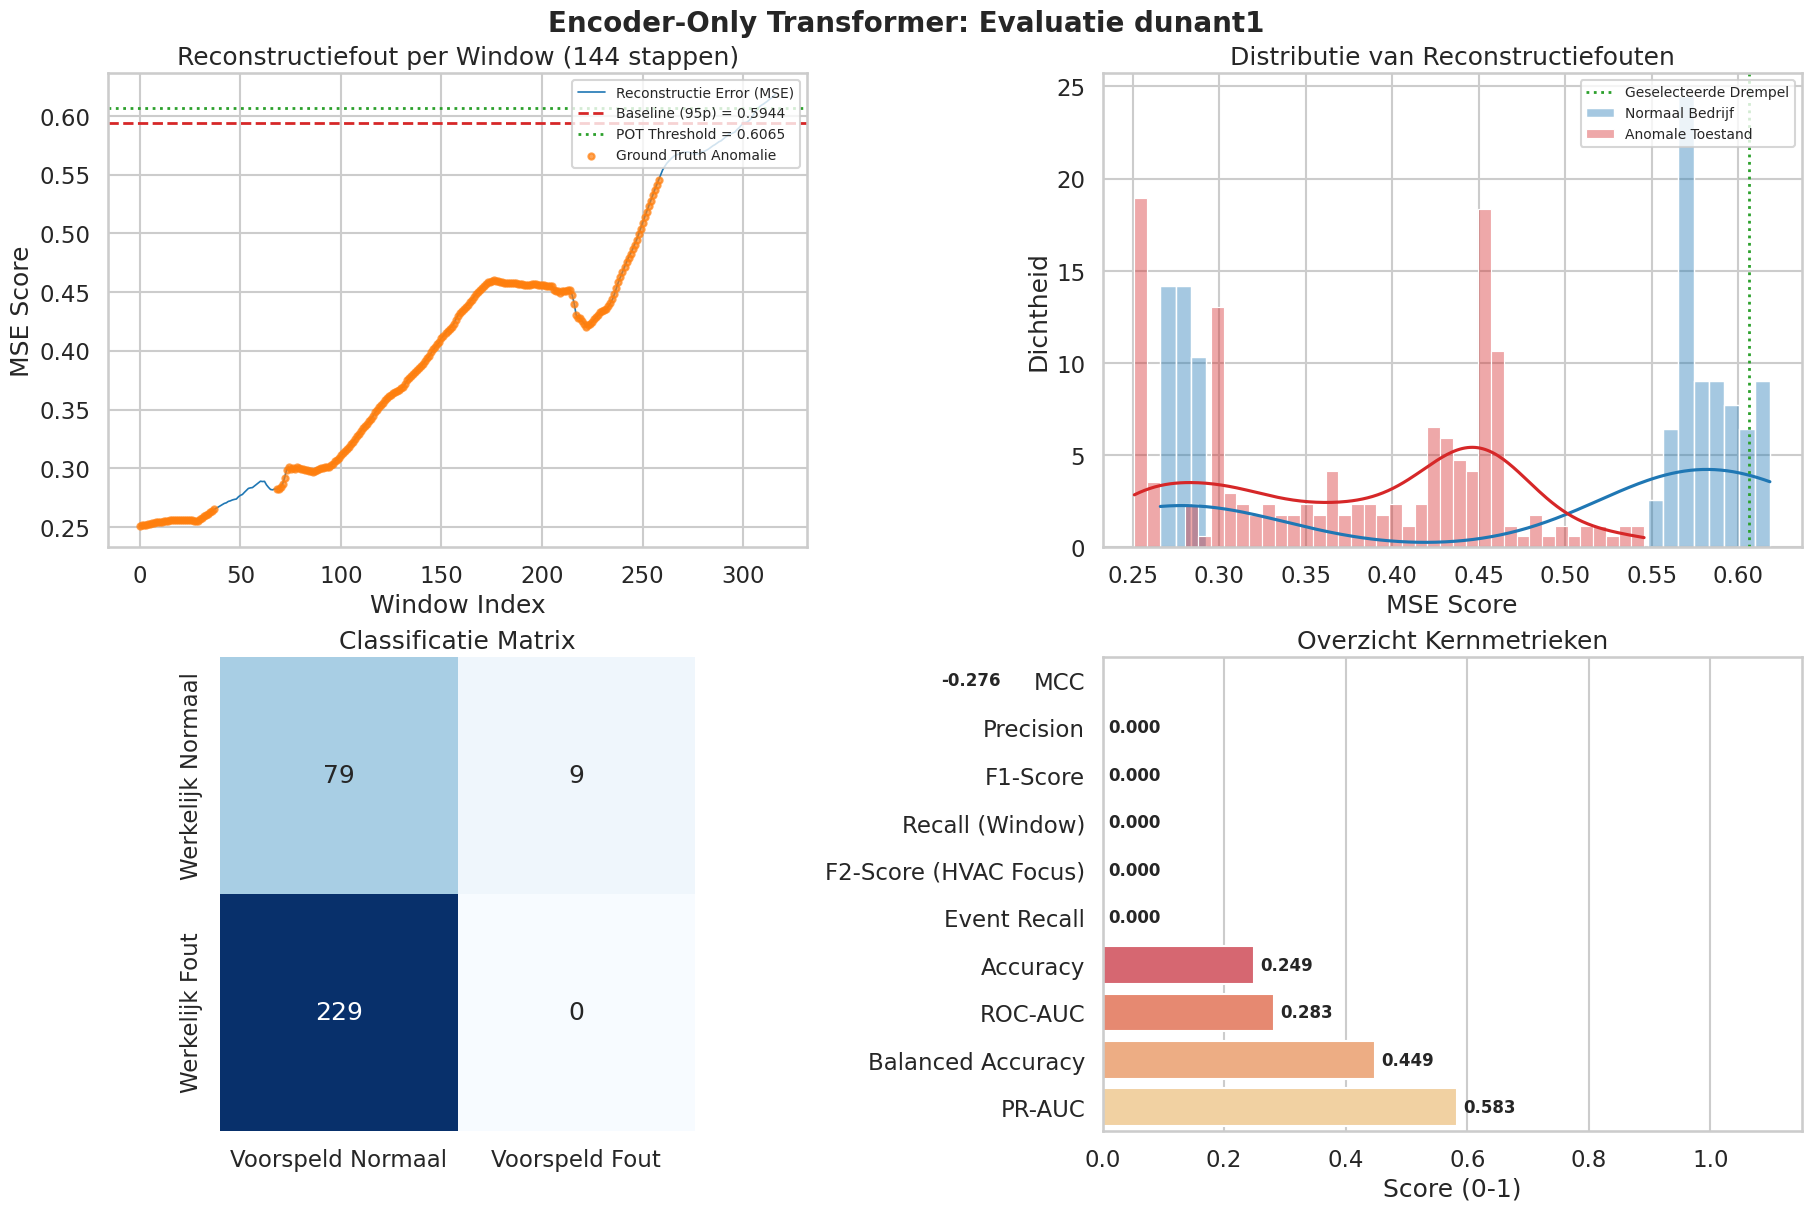

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Voorbereiden van de data uit de scorecard
metrics_best_df = tuned_result['metrics_df']
cm_best = tuned_result['confusion_matrix']
y_pred_eval_best = tuned_result['y_pred_window']

# Print de ruwe resultaten voor snelle controle
print(metrics_best_df.to_string(index=False))
print('\nEvent details:', tuned_result['event_details'])

# 2. Visualisaties opzetten
sns.set_theme(style='whitegrid', context='talk')
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
fig.suptitle(f'Encoder-Only Transformer: Evaluatie {GEBOUW}', fontsize=20, fontweight='bold')

# --- PLOT 1: Anomaly scores over de windows ---
ax1 = axes[0, 0]
ax1.plot(eval_scores_best, color='#1f77b4', linewidth=1.2, label='Reconstructie Error (MSE)')
ax1.axhline(baseline_threshold_best, color='#d62728', linestyle='--', linewidth=2, 
            label=f'Baseline (95p) = {baseline_threshold_best:.4f}')
ax1.axhline(tuned_threshold_best, color='#2ca02c', linestyle=':', linewidth=2, 
            label=f'POT Threshold = {tuned_threshold_best:.4f}')

# Highlight de ground truth anomalieën
anom_idx = np.where(y_true_window == 1)[0]
ax1.scatter(anom_idx, eval_scores_best[anom_idx], s=20, color='#ff7f0e', alpha=0.7, 
            label='Ground Truth Anomalie', zorder=5)

ax1.set_title('Reconstructiefout per Window (144 stappen)')
ax1.set_xlabel('Window Index')
ax1.set_ylabel('MSE Score')
ax1.legend(loc='upper right', fontsize=10)

# --- PLOT 2: Scoreverdeling per klasse (KDE) ---
ax2 = axes[0, 1]
# We splitsen de scores op basis van de werkelijke labels
sns.histplot(eval_scores_best[y_true_window == 0], bins=40, kde=True, stat='density', 
             color='#1f77b4', alpha=0.4, label='Normaal Bedrijf', ax=ax2)
sns.histplot(eval_scores_best[y_true_window == 1], bins=40, kde=True, stat='density', 
             color='#d62728', alpha=0.4, label='Anomale Toestand', ax=ax2)

ax2.axvline(tuned_threshold_best, color='#2ca02c', linestyle=':', linewidth=2, label='Geselecteerde Drempel')
ax2.set_title('Distributie van Reconstructiefouten')
ax2.set_xlabel('MSE Score')
ax2.set_ylabel('Dichtheid')
ax2.legend(loc='upper right', fontsize=10)

# --- PLOT 3: Confusion Matrix ---
ax3 = axes[1, 0]
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False, square=True,
            xticklabels=['Voorspeld Normaal', 'Voorspeld Fout'],
            yticklabels=['Werkelijk Normaal', 'Werkelijk Fout'], ax=ax3)
ax3.set_title('Classificatie Matrix')

# --- PLOT 4: Metric Overview ---
ax4 = axes[1, 1]
# Sorteren voor een mooie barplot
metric_plot_df = metrics_best_df.sort_values('Value', ascending=True)
sns.barplot(data=metric_plot_df, x='Value', y='Metric', palette='magma', ax=ax4)

# Voeg de waarden toe als tekstlabels
for i, value in enumerate(metric_plot_df['Value']):
    ax4.text(value + 0.01, i, f'{value:.3f}', va='center', fontsize=12, fontweight='bold')

ax4.set_xlim(0, 1.15)
ax4.set_title('Overzicht Kernmetrieken')
ax4.set_xlabel('Score (0-1)')
ax4.set_ylabel('')

plt.show()